In [48]:
import os
import pickle
import h5py
import json

import numpy as np
import matplotlib.pyplot as plt

import matplotlib.patheffects as patheffects
%matplotlib widget

In [10]:
from pyFAI.azimuthalIntegrator import AzimuthalIntegrator
from pyFAI.detectors import Detector

from ePDF.DAG.diffraction import integrate_single
from ePDF.DAG.pdf import pdf_optimize

In [11]:
with h5py.File('data/TiO2_dataset.h5', 'r') as f:
    # Load the datacube into memory
    X = np.array(f['X4D'])
    Xr = np.array(f['coordinates/x_real'])
    Yr = np.array(f['coordinates/y_real'])
    Xq = np.array(f['coordinates/x_reciprocal'])
    Yq = np.array(f['coordinates/y_reciprocal'])
    meta = json.loads(f['metadata'][()])
    beamstop = np.array(f['coordinates/beamstop'])

x_real, y_real, x_reci, y_reci = X.shape

Xf = X.reshape(X.shape[0] * X.shape[1], X.shape[2] * X.shape[3])
Xf = Xf.clip(min=0, max=1e32)

print(x_real, y_real, x_reci, y_reci)

26 78 187 187


In [45]:
if os.path.exists('factorizations/TiO2_nmf_N2.pkl'):
    with open('factorizations/TiO2_nmf_N2.pkl', 'rb') as f:
        W_N2, H_N2 = pickle.load(f)

if os.path.exists('factorizations/TiO2_nmf_NQ2.pkl'):
    with open('factorizations/TiO2_nmf_NQ2.pkl', 'rb') as f:
        W_NQ2, H_NQ2 = pickle.load(f)

# if os.path.exists('factorizations/TiO2_nmf_NQ2_100.pkl'):
#     with open('factorizations/TiO2_nmf_NQ2_100.pkl', 'rb') as f:
#         W_NQ2_100, H_NQ2_100 = pickle.load(f)

scale = H_N2.max(axis=1)
H_N2 /= scale[:, np.newaxis]
W_N2 *= scale

scale = H_NQ2.max(axis=1)
H_NQ2 /= scale[:, np.newaxis]
W_NQ2 *= scale

# scale = H_NQ2_100.max(axis=1)
# H_NQ2_100 /= scale[:, np.newaxis]
# W_NQ2_100 *= scale

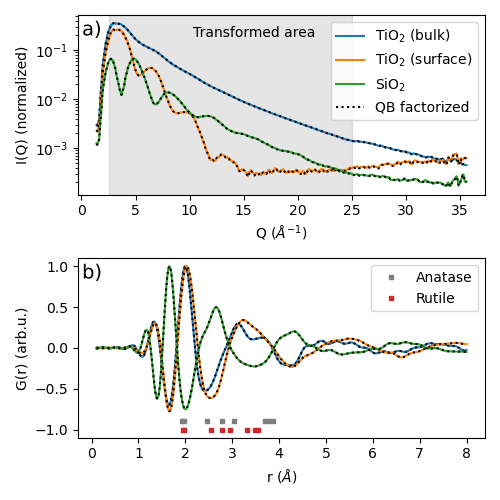

In [ ]:
fig, axs = plt.subplots(nrows=2, ncols=1, figsize=(5, 5))


labels = ['TiO$_2$ (bulk)', 'SiO$_2$', 'TiO$_2$ (surface)']
for i in [0,2,1]:

    ccomp = H_N2[i, :].reshape((x_reci, y_reci))
    # beamstop[:, :] = False
    QA, I, ai = integrate_single(ccomp, meta, beamstop.T, ai_res=2**11, return_AI=True)
    pdfr, pdfgr, [qmin, qmax, p] = pdf_optimize(QA, I, qmin=2.5, qmax=20, rpolyrange=np.arange(1, 2, 0.01))

    l, = axs[0].plot(QA, I, label=labels[i])
    axs[1].plot(pdfr[pdfr < 8], pdfgr[pdfr < 8]/pdfgr.max())

    ccomp = H_NQ2[i, :].reshape((x_reci, y_reci))
    # beamstop[:, :] = False
    QA, I, ai = integrate_single(ccomp, meta, beamstop.T, ai_res=2**11, return_AI=True)
    pdfr, pdfgr, [qmin, qmax, p] = pdf_optimize(QA, I, qmin=2.5, qmax=20, rpolyrange=np.arange(1, 2, 0.01))

    axs[0].plot(QA, I, 'k:')
    axs[1].plot(pdfr[pdfr < 8], pdfgr[pdfr < 8]/pdfgr.max(), 'k:')

    # ccomp = H_NQ2_100[i, :].reshape((x_reci, y_reci))
    # # beamstop[:, :] = False
    # QA, I, ai = integrate_single(ccomp, meta, beamstop.T, ai_res=2**11, return_AI=True)
    # pdfr, pdfgr, [qmin, qmax, p] = pdf_optimize(QA, I, qmin=2.5, qmax=20, rpolyrange=np.arange(1, 2, 0.01))

    # axs[0].plot(QA, I, ':', color=l.get_color())
    # axs[1].plot(pdfr[pdfr < 8], pdfgr[pdfr < 8]/pdfgr.max(), ':', color=l.get_color())


    axs[0].set_yscale('log')
    axs[0].set_ylabel ('I(Q) (normalized)')
    axs[0].set_xlabel('Q ($\AA^{-1}$)')


    
    axs[1].set_xlabel('r ($\AA$)')
    axs[1].set_ylabel('G(r) (arb.u.)')

axs[0].axvspan(2.5, 25, color='gray', alpha=0.2)
axs[0].text(16, 0.88, 'Transformed area', transform=axs[0].get_xaxis_transform(), ha='center')

axs[0].plot([], [], 'k:', label='QB factorized')
axs[0].legend()


anatase = np.array([1.93, 1.98, 2.47, 2.79, 3.04, 3.7, 3.78, 3.86])
rutile = np.array([1.95, 1.98, 2.54,2.78,2.96,3.32,3.49,3.56])

axs[0].text(0.01, 0.97, 'a)', transform=axs[0].transAxes, fontsize=14, va='top', ha='left',
    color='k', path_effects=[patheffects.withStroke(linewidth=1, foreground='w')])
axs[1].text(0.01, 0.97, 'b)', transform=axs[1].transAxes, fontsize=14, va='top', ha='left',
    color='k', path_effects=[patheffects.withStroke(linewidth=1, foreground='w')])

axs[1].plot(anatase, -0.9*np.ones(anatase.size), 's', ms = 3, color='tab:grey', label='Anatase')
axs[1].plot(rutile, -1*np.ones(rutile.size), 's', ms = 3, color='tab:red', label='Rutile')

axs[1].legend()

plt.tight_layout()
plt.savefig('figures/TiO2_gr.png', dpi=300)